Regression Model Performance:
                    Model      MAE       MSE     RMSE  R2 Score
        Linear Regression 3.189092 24.291119 4.928602  0.668759
Support Vector Regression 2.731716 25.668540 5.066413  0.649977
 Decision Tree Regression 2.394118 10.416078 3.227395  0.857963


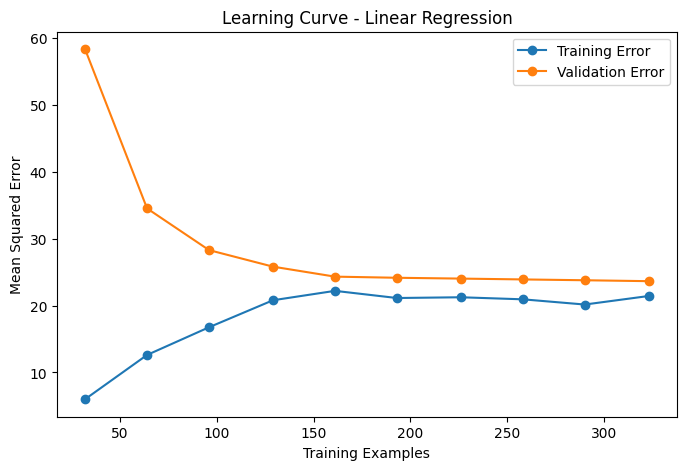

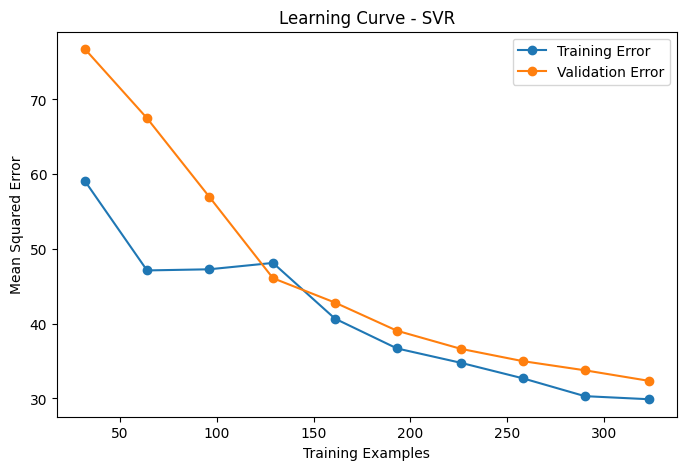

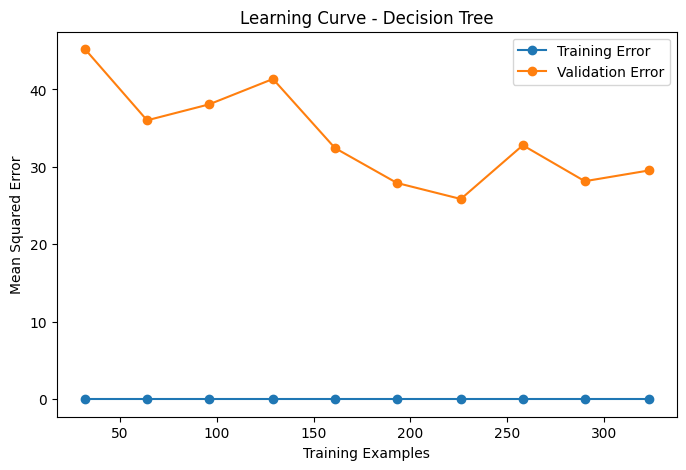


Task 3 Completed Successfully.
Name: Karthik


In [1]:
# Experiment 04 - Task 03
# Learning Curves and Regression Evaluation
# Name: Karthik
# Roll number;25Eu02904


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Boston Housing Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

# Features and target
X = df.drop("medv", axis=1)
y = df["medv"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Scale data for Linear Regression and SVR
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
lr_model = LinearRegression()

svr_model = SVR(kernel="rbf")

dt_model = DecisionTreeRegressor(random_state=42)

# Train models
lr_model.fit(X_train_scaled, y_train)

svr_model.fit(X_train_scaled, y_train)

dt_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_scaled)

svr_predictions = svr_model.predict(X_test_scaled)

dt_predictions = dt_model.predict(X_test)

# Function for metrics
def calculate_metrics(y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)
    return mae, mse, rmse, r2

# Calculate metrics
lr_metrics = calculate_metrics(
    y_test,
    lr_predictions
)

svr_metrics = calculate_metrics(
    y_test,
    svr_predictions
)

dt_metrics = calculate_metrics(
    y_test,
    dt_predictions
)

# Comparison table
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        lr_metrics[0],
        svr_metrics[0],
        dt_metrics[0]
    ],
    "MSE": [
        lr_metrics[1],
        svr_metrics[1],
        dt_metrics[1]
    ],
    "RMSE": [
        lr_metrics[2],
        svr_metrics[2],
        dt_metrics[2]
    ],
    "R2 Score": [
        lr_metrics[3],
        svr_metrics[3],
        dt_metrics[3]
    ]
})

print("Regression Model Performance:")
print(results.to_string(index=False))

# -----------------------------
# Learning Curve - Linear Regression
# -----------------------------

train_sizes, train_scores, validation_scores = learning_curve(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_error = -train_scores.mean(axis=1)

validation_error = -validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_error,
    marker="o",
    label="Training Error"
)

plt.plot(
    train_sizes,
    validation_error,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - Linear Regression")
plt.legend()
plt.show()

# -----------------------------
# Learning Curve - SVR
# -----------------------------

train_sizes_svr, train_scores_svr, validation_scores_svr = learning_curve(
    SVR(kernel="rbf"),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_error_svr = -train_scores_svr.mean(axis=1)

validation_error_svr = -validation_scores_svr.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes_svr,
    train_error_svr,
    marker="o",
    label="Training Error"
)

plt.plot(
    train_sizes_svr,
    validation_error_svr,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - SVR")
plt.legend()
plt.show()

# -----------------------------
# Learning Curve - Decision Tree
# -----------------------------

train_sizes_dt, train_scores_dt, validation_scores_dt = learning_curve(
    DecisionTreeRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_error_dt = -train_scores_dt.mean(axis=1)

validation_error_dt = -validation_scores_dt.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes_dt,
    train_error_dt,
    marker="o",
    label="Training Error"
)

plt.plot(
    train_sizes_dt,
    validation_error_dt,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - Decision Tree")
plt.legend()
plt.show()

print("\nTask 3 Completed Successfully.")
print("Name: Karthik")